# Recurring Operations: Group Comparison Analysis

Methods covered:
  1. Kaplan-Meier + log-rank (time to first re-operation)
  2. Cox Proportional Hazards (time to first re-operation)
  3. Andersen-Gill model (all re-operations, independent increments)
  4. Prentice-Williams-Peterson (PWP) model (ordered recurring events)
  5. Negative Binomial regression (total count of re-operations)
  6. Mean Cumulative Function (MCF) plot

# Customization

In [404]:
# ---- 0. Install / load packages ----
pkgs <- c("survival", "survminer", "MASS", "dplyr", "ggplot2", "tibble",
          "readxl", "lubridate", "ggbeeswarm")
new_pkgs <- pkgs[!pkgs %in% installed.packages()[, "Package"]]
if (length(new_pkgs)) install.packages(new_pkgs)
invisible(lapply(pkgs, library, character.only = TRUE))

set.seed(42)


In [405]:
# ---- Plot dimensions (width x height in inches) ----
options(repr.plot.width = 12, repr.plot.height = 8)


# 1. LOAD DATA
Read from `lor.xlsx`, sheet **"данные"**.

Columns used:
- `группа`
- `id` — идентификатор пациента
- `возраст`
- `пол`
- `длительность заболевания`
- `удаление полипов в анамнезе` — количество предыдущих удалений полипов
- `дата операции` — дата индексной операции
- `оперированные пазухи` — количество оперированных пазух
- `операция 1` / `дата операции 1` — 1-я повторная операция (да/нет + дата)
- `операция 2` / `дата операции 2` — 2-я повторная операция (да/нет + дата)

Длительность наблюдения измеряется в **днях** с момента индексной операции.  
Пациенты без последующего события цензурированы на последнюю дату, наблюдаемую в наборе данных.  
Для удобства используется константа `six_months_days = 365.25 / 2 ≈ 182.6` для интервалов на оси.


In [406]:
# ---- Read raw data ----
raw <- read_excel(
  "C:\\Analysis\\OTOLARING\\Nidelko\\lor.xlsx",
  sheet = "данные"
)

# ---- Select and rename columns ----
data <- raw |>
  transmute(
    id       = as.character(`id`),
    group    = factor(`группа`),
    age      = as.integer(`возраст`),
    sex      = `пол`,
    ill_dur  = as.integer(`длительность заболевания`),
    polyps   = `удаление полипов в анамнезе`,
    date_operation = as.Date(`дата операции`),
    sinuses  = `оперированные пазухи`,
    reop1    = as.integer(tolower(`операция 1`) == "да"),
    date_reoperation1 = as.Date(`дата операции 1`),
    reop2    = as.integer(tolower(`операция 2`) == "да"),
    date_reoperation2 = as.Date(`дата операции 2`)
  )

# ---- Helper: days between two dates ----
days_diff <- function(d_start, d_end) {
  as.numeric(difftime(as.Date(d_end), as.Date(d_start), units = "days"))
}

# 6 months in days (used for axis breaks)
six_months_days <- 365.25 / 2   # 182.625

# ---- Study end = latest date observed across all patients ----
study_end <- max(c(data$date_reoperation2, data$date_reoperation1, data$date_operation), na.rm = TRUE)
cat(sprintf("Study end date (latest observed): %s\n\n", as.character(study_end)))

# ---- Patient-level summary (one row per patient) ----
patient_df <- data |>
  mutate(
    n_reops  = reop1 + reop2,
    followup = days_diff(date_operation, study_end)
  )

cat(sprintf("Patients loaded: %d\n", nrow(patient_df)))
cat(sprintf("Groups: %s\n\n", paste(levels(patient_df$group), collapse = ", ")))

print(patient_df)

Study end date (latest observed): 2026-01-21

Patients loaded: 50
Groups: КГ, ОГ1, ОГ2

# A tibble: 50 × 14
   id    group   age sex   ill_dur polyps date_operation sinuses reop1
   <chr> <fct> <int> <chr>   <int>  <dbl> <date>           <dbl> <int>
 1 1     ОГ1      48 муж.       10      3 2021-11-25           4     0
 2 2     ОГ1      32 муж.       20      1 2022-01-21           2     0
 3 4     ОГ1      50 муж.       15      3 2021-12-22           8     0
 4 5     ОГ1      28 муж.        8      7 2022-01-18           4     1
 5 6     ОГ1      37 муж.        8      3 2022-03-02           1     0
 6 7     ОГ1      23 жен.        8      2 2022-03-29           8     0
 7 9     ОГ1      58 муж.       10      3 2022-05-20           4     1
 8 10    ОГ1      63 муж.       15      4 2022-06-02           2     0
 9 11    ОГ1      43 муж.       25      3 2023-01-26           2     0
10 12    ОГ1      55 муж.       15      2 2022-05-19           8     0
# ℹ 40 more rows
# ℹ 5 more variables: d

In [407]:
# ---- Patient-level summary table ----
cat("=== Patient summary ===\n")
patient_df |>
  group_by(group) |>
  summarise(
    n            = n(),
    median_fup   = round(median(followup), 1),
    mean_reops   = round(mean(n_reops), 2),
    pct_any_reop = round(mean(n_reops > 0) * 100, 1)
  ) |>
  print()

=== Patient summary ===
# A tibble: 3 × 5
  group     n median_fup mean_reops pct_any_reop
  <fct> <int>      <dbl>      <dbl>        <dbl>
1 КГ       25      1071        0.44         36  
2 ОГ1      12      1368.       0.17         16.7
3 ОГ2      13      1022        0.08          7.7


In [408]:
# ---- Derive palette from actual group levels ----
group_levels <- levels(patient_df$group)
n_groups     <- length(group_levels)

# Base set of distinguishable colors; extend if more groups are added
base_colors  <- c("#E74C3C", "#2ECC71", "#3498DB", "#9B59B6",
                  "#F39C12", "#1ABC9C", "#E67E22", "#2980B9")
group_palette <- setNames(base_colors[seq_len(n_groups)], group_levels)

cat(sprintf("Groups (%d): %s\n", n_groups, paste(group_levels, collapse = ", ")))
cat("Palette:\n")
print(group_palette)

Groups (3): КГ, ОГ1, ОГ2
Palette:
       КГ       ОГ1       ОГ2 
"#E74C3C" "#2ECC71" "#3498DB" 


# 2. DATA FORMATS

## Follow-up time description

Follow-up is the number of days from the index operation to the study end date (administrative censoring).
Basic statistics are shown overall and by group, followed by a beeswarm plot.


In [409]:
# ---- Follow-up time: basic statistics ----
fup_stats <- function(x) {
  tibble(
    n      = length(x),
    mean   = round(mean(x),   1),
    sd     = round(sd(x),     1),
    median = round(median(x), 1),
    q1     = round(quantile(x, 0.25), 1),
    q3     = round(quantile(x, 0.75), 1),
    min    = round(min(x), 1),
    max    = round(max(x), 1)
  )
}

cat("=== Follow-up time (days) — all patients ===\n")
print(fup_stats(patient_df$followup))

cat("\n=== Follow-up time (days) — by group ===\n")
patient_df |>
  group_by(group) |>
  summarise(fup_stats(followup), .groups = "drop") |>
  print()


=== Follow-up time (days) — all patients ===


# A tibble: 1 × 8
      n  mean    sd median    q1    q3   min   max
  <int> <dbl> <dbl>  <dbl> <dbl> <dbl> <dbl> <dbl>
1    50 1149.  193.   1087 1020.  1342   826  1518

=== Follow-up time (days) — by group ===
# A tibble: 3 × 9
  group     n  mean    sd median    q1    q3   min   max
  <fct> <int> <dbl> <dbl>  <dbl> <dbl> <dbl> <dbl> <dbl>
1 КГ       25 1107. 183.   1071   994  1141    826  1497
2 ОГ1      12 1365. 126.   1368. 1339. 1462.  1091  1518
3 ОГ2      13 1030.  74.8  1022  1007  1041    901  1167


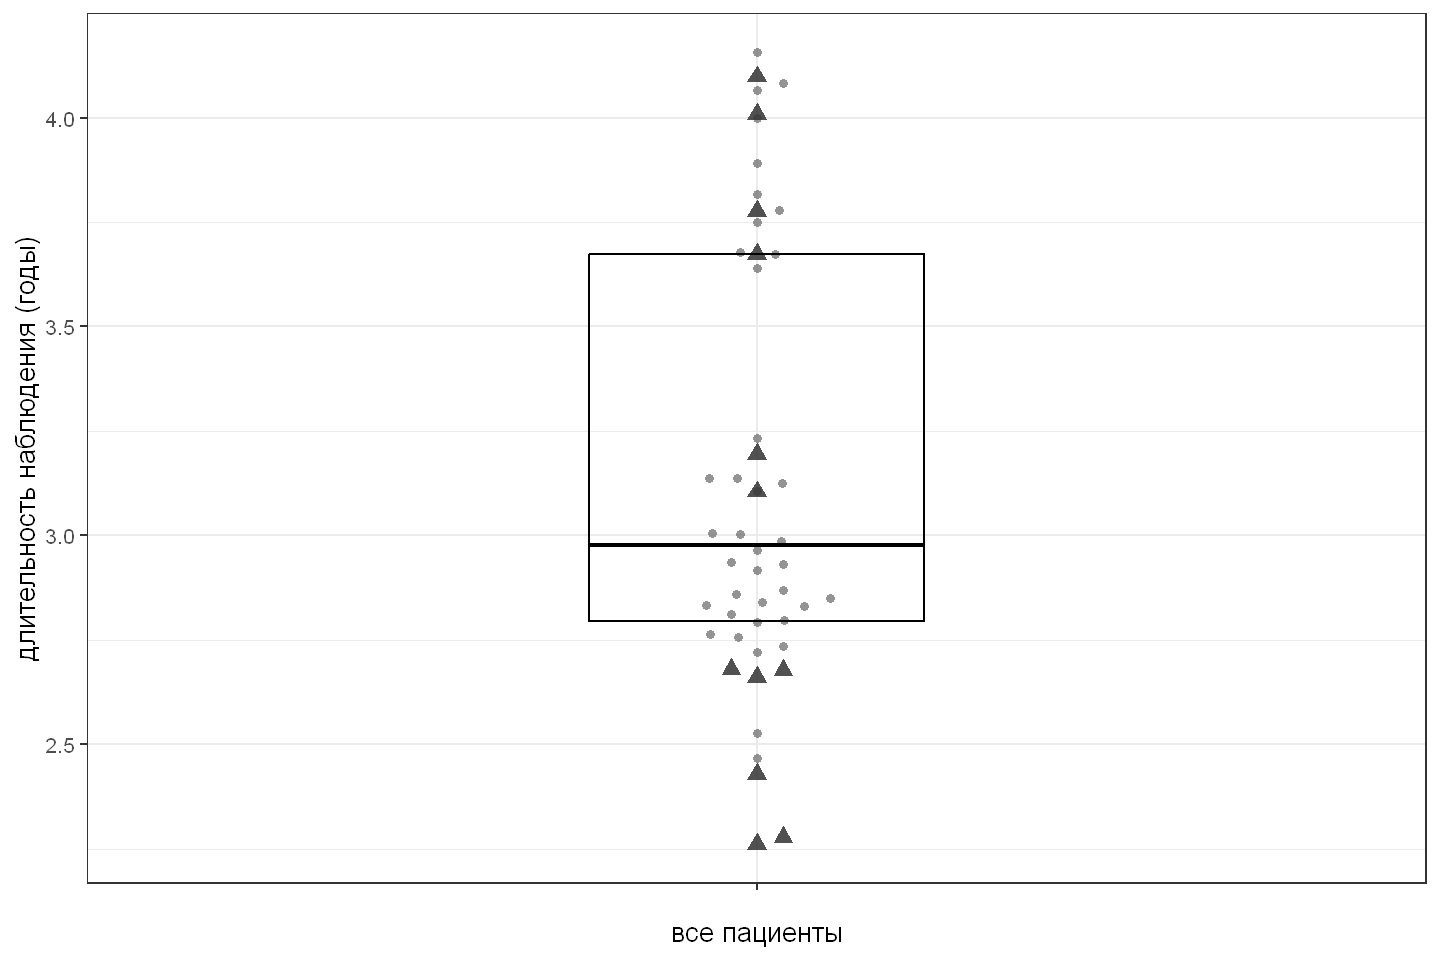

In [410]:
# ---- Follow-up time: beeswarm — all patients ----

fup_all_df <- patient_df |>
  mutate(fup_years = followup / 365.25)

y_breaks <- seq(0, ceiling(max(fup_all_df$fup_years)), by = 0.5)

fup_beeswarm_all <- ggplot(fup_all_df, aes(x = "", y = fup_years)) +
  geom_beeswarm(
    data   = ~subset(., reop1 == 0 & reop2 == 0),
    cex = 2.5, size = 2.0, shape = 16, alpha = 0.7, colour = "grey40"
  ) +
  geom_beeswarm(
    data   = ~subset(., reop1 == 1 | reop2 == 1),
    cex = 2.5, size = 3.8, shape = 17, alpha = 0.85, colour = "grey20"
  ) +
  stat_summary(
    fun.data = median_hilow, fun.args = list(conf.int = 0.5),
    geom = "crossbar", width = 0.3, linewidth = 0.6,
    colour = "black", fatten = 2
  ) +
  scale_y_continuous(breaks = y_breaks) +
  labs(
    x        = "все пациенты",
    y        = "длительность наблюдения (годы)"
  ) +
  theme_bw(base_size = 16)


print(fup_beeswarm_all)

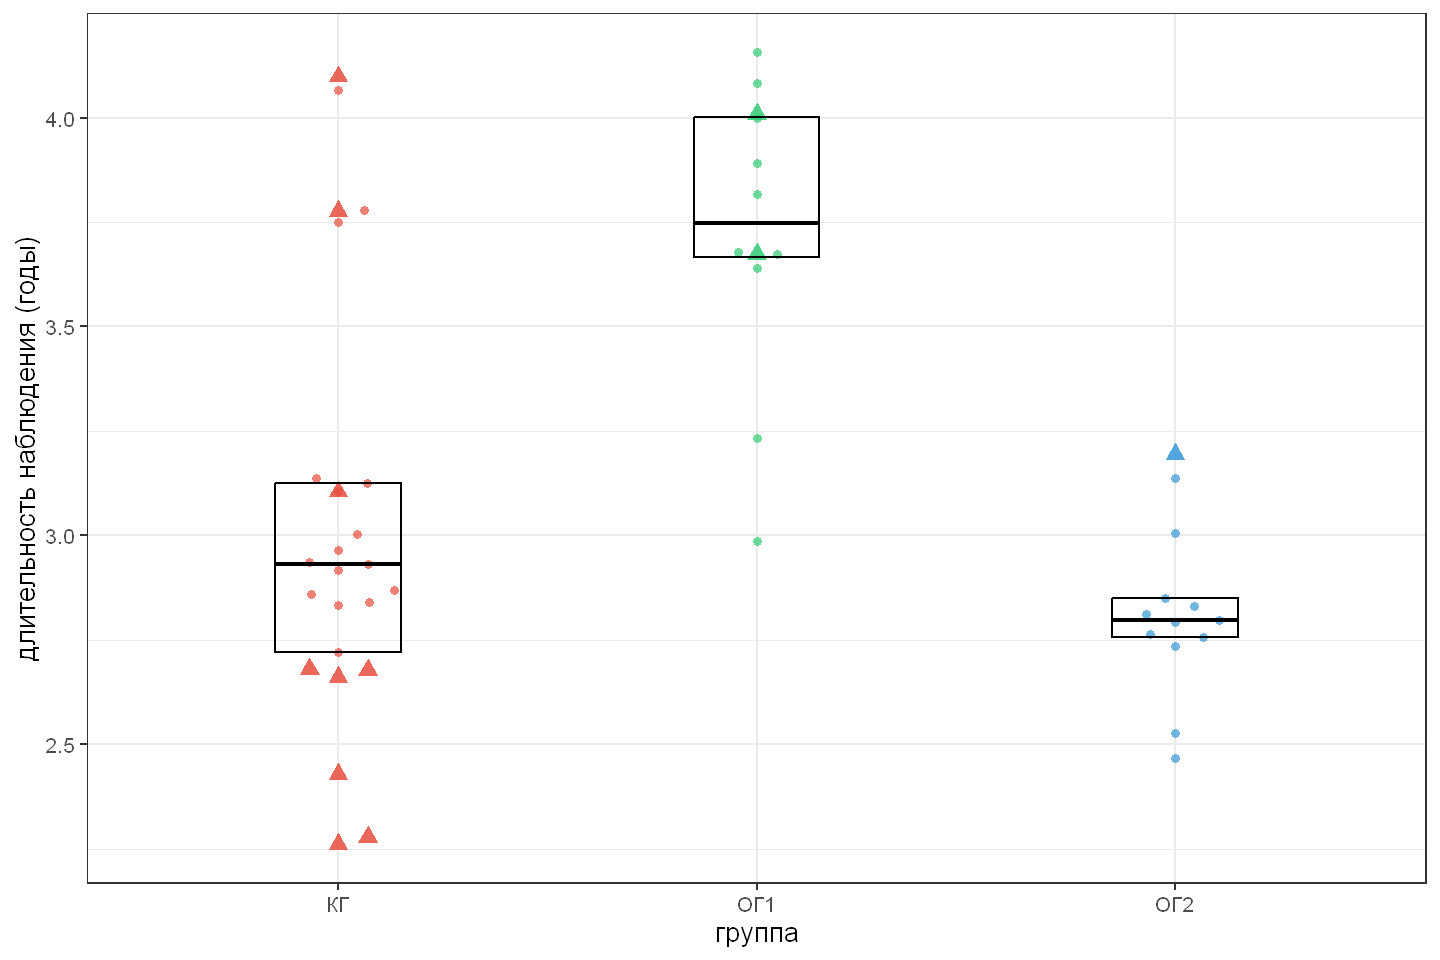

In [411]:
# ---- Follow-up time: beeswarm — by group ----

fup_grp_df <- patient_df |>
  mutate(fup_years = followup / 365.25)

fup_beeswarm_grp <- ggplot(fup_grp_df, aes(x = group, y = fup_years, colour = group)) +
  geom_beeswarm(
    data   = ~subset(., reop1 == 0 & reop2 == 0),
    cex = 2.5, size = 2.0, shape = 16, alpha = 0.7
  ) +
  geom_beeswarm(
    data   = ~subset(., reop1 == 1 | reop2 == 1),
    cex = 2.5, size = 3.8, shape = 17, alpha = 0.85
  ) +
  stat_summary(
    fun.data = median_hilow, fun.args = list(conf.int = 0.5),
    geom = "crossbar", width = 0.3, linewidth = 0.6,
    colour = "black", fatten = 2
  ) +
  scale_colour_manual(values = group_palette, guide = "none") +
  scale_y_continuous(breaks = y_breaks) +
  labs(
    x        = "группа",
    y        = "длительность наблюдения (годы)"
  ) +
  theme_bw(base_size = 16)


print(fup_beeswarm_grp)

In [412]:
# ---- 2a. Wide format: one row per patient, time to first re-op ----
first_reop_df <- patient_df |>
  mutate(
    time_first  = ifelse(
      reop1 == 1,
      days_diff(date_operation, date_reoperation1),
      followup
    ),
    event_first = as.integer(reop1 == 1)
  )
head(first_reop_df)


id,group,age,sex,ill_dur,polyps,date_operation,sinuses,reop1,date_reoperation1,reop2,date_reoperation2,n_reops,followup,time_first,event_first
<chr>,<fct>,<int>,<chr>,<int>,<dbl>,<date>,<dbl>,<int>,<date>,<int>,<date>,<int>,<dbl>,<dbl>,<int>
1,ОГ1,48,муж.,10,3,2021-11-25,4,0,NA,0,NA,0,1518,1518,0
2,ОГ1,32,муж.,20,1,2022-01-21,2,0,NA,0,NA,0,1461,1461,0
4,ОГ1,50,муж.,15,3,2021-12-22,8,0,NA,0,NA,0,1491,1491,0
5,ОГ1,28,муж.,8,7,2022-01-18,4,1,2023-07-13,0,NA,1,1464,541,1
6,ОГ1,37,муж.,8,3,2022-03-02,1,0,NA,0,NA,0,1421,1421,0
7,ОГ1,23,жен.,8,2,2022-03-29,8,0,NA,0,NA,0,1394,1394,0


In [413]:
# ---- 2b. Long (counting process) format: one row per event interval ----
# Format:  id | group | tstart | tstop | status | event_num
# Used for: Andersen-Gill, PWP, MCF
make_long_format <- function(df) {

  rows <- vector("list", nrow(df))

  for (i in seq_len(nrow(df))) {
    pid  <- df$id[i]
    grp  <- as.character(df$group[i])
    fup  <- df$followup[i]

    # Event times in days from index operation
    et <- numeric(0)
    if (df$reop1[i] == 1) et <- c(et, days_diff(df$date_operation[i], df$date_reoperation1[i]))
    if (df$reop2[i] == 1) et <- c(et, days_diff(df$date_operation[i], df$date_reoperation2[i]))
    et <- sort(et)

    if (length(et) == 0) {
      # No events: single censored interval [0, followup)
      rows[[i]] <- tibble(
        id        = pid,
        group     = grp,
        tstart    = 0,
        tstop     = fup,
        status    = 0L,
        event_num = 1L
      )
    } else {
      times  <- c(0, et, fup)
      n_int  <- length(times) - 1
      rows[[i]] <- tibble(
        id        = pid,
        group     = grp,
        tstart    = times[1:n_int],
        tstop     = times[2:(n_int + 1)],
        status    = c(rep(1L, length(et)), 0L),
        event_num = seq_len(n_int)
      )
    }
  }

  bind_rows(rows) |>
    mutate(group = factor(group))
}


# 3. KAPLAN-MEIER + LOG-RANK  (time to first re-operation)

Call: survfit(formula = Surv(time_first, event_first) ~ group, data = first_reop_df)

           n events median 0.95LCL 0.95UCL
group=КГ  25      9     NA     968      NA
group=ОГ1 12      2     NA      NA      NA
group=ОГ2 13      1     NA      NA      NA

Log-rank test:
Call:
survdiff(formula = Surv(time_first, event_first) ~ group, data = first_reop_df)

           N Observed Expected (O-E)^2/E (O-E)^2/V
group=КГ  25        9     5.48     2.262      4.23
group=ОГ1 12        2     3.58     0.701      1.10
group=ОГ2 13        1     2.94     1.277      1.74

 Chisq= 4.3  on 2 degrees of freedom, p= 0.1 
Log-rank p-value: 0.1177


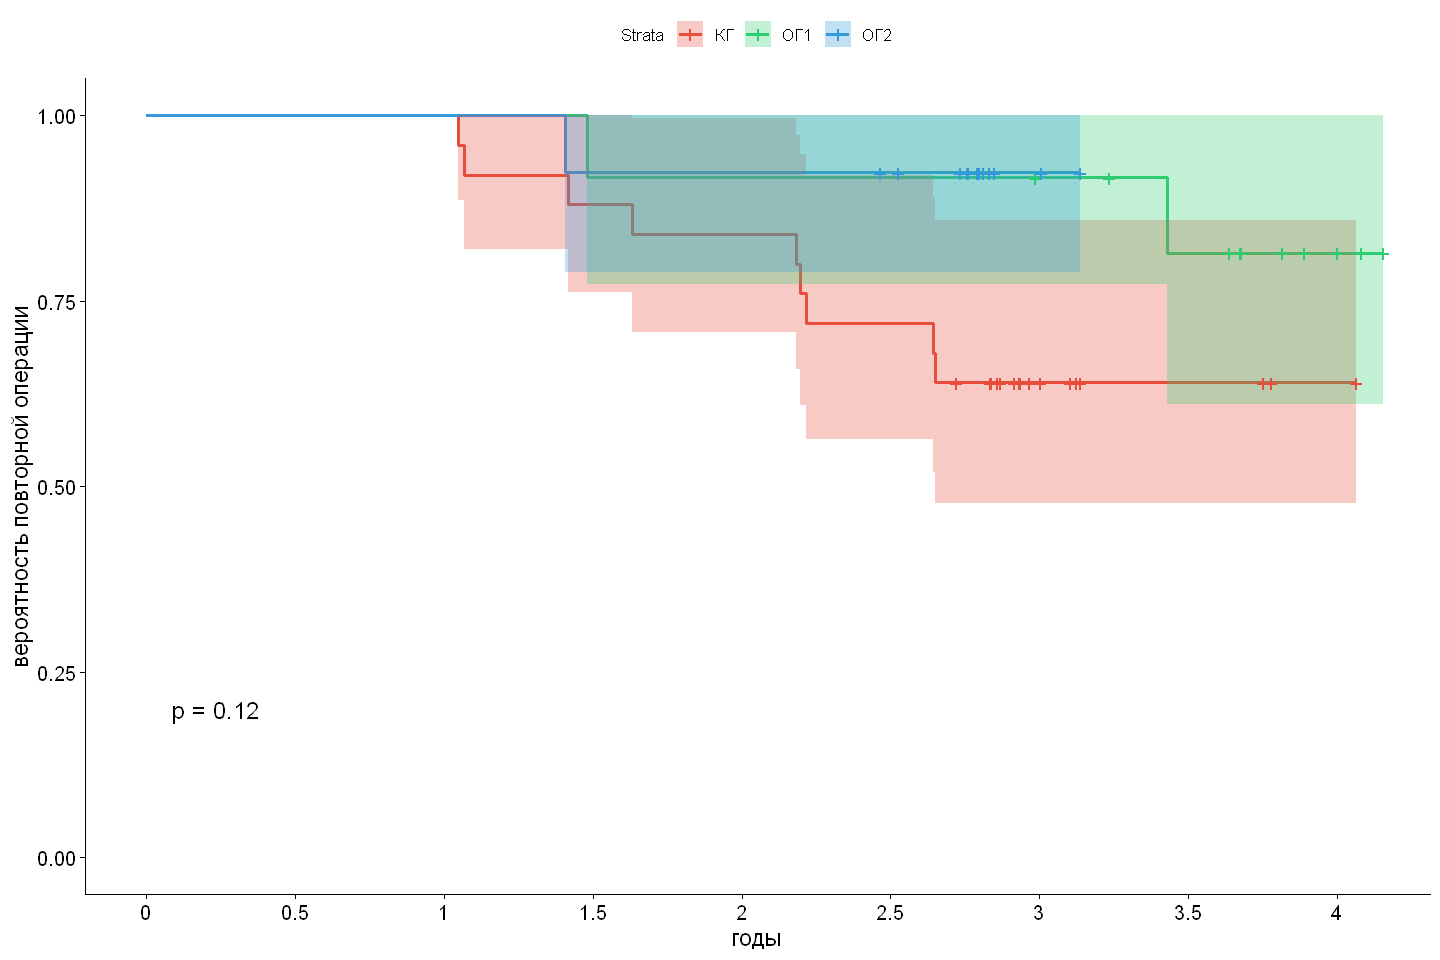

In [414]:
km_fit <- survfit(Surv(time_first, event_first) ~ group, data = first_reop_df)
print(km_fit)

# Log-rank test
logrank <- survdiff(Surv(time_first, event_first) ~ group, data = first_reop_df)
cat("\nLog-rank test:\n")
print(logrank)

# P-value
p_logrank <- pchisq(logrank$chisq, df = length(logrank$n) - 1, lower.tail = FALSE)
cat(sprintf("Log-rank p-value: %.4f\n", p_logrank))

# Plot
km_plot <- ggsurvplot(
  km_fit,
  data           = first_reop_df,
  pval           = TRUE,
  conf.int       = TRUE,
  risk.table     = FALSE,
  palette        = group_palette,
  xlab           = "годы",
  ylab           = "вероятность повторной операции",
  legend.labs    = group_levels,
  break.time.by  = six_months_days,  # tick every 0.5 years
  xscale         = 365.25            # convert day values to year labels
)

print(km_plot)

In [415]:
# Survival estimates at every 6 months (half-year intervals)
half_year_times <- seq(six_months_days,
                       max(first_reop_df$time_first, na.rm = TRUE),
                       by = six_months_days)
km_summary <- summary(km_fit, times = half_year_times, extend = TRUE)
print(km_summary)


Call: survfit(formula = Surv(time_first, event_first) ~ group, data = first_reop_df)

                group=КГ 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
  183     25       0     1.00  0.0000        1.000        1.000
  365     25       0     1.00  0.0000        1.000        1.000
  548     22       3     0.88  0.0650        0.761        1.000
  730     21       1     0.84  0.0733        0.708        0.997
  913     18       3     0.72  0.0898        0.564        0.919
 1096      7       2     0.64  0.0960        0.477        0.859
 1278      3       0     0.64  0.0960        0.477        0.859
 1461      1       0     0.64  0.0960        0.477        0.859

                group=ОГ1 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
  183     12       0    1.000  0.0000        1.000            1
  365     12       0    1.000  0.0000        1.000            1
  548     11       1    0.917  0.0798        0.773            1
  730     11       0    0.91

# 4. COX PROPORTIONAL HAZARDS  (time to first re-operation)

## 4.1  Unadjusted — group only


In [416]:
cox_fit <- coxph(Surv(time_first, event_first) ~ group, data = first_reop_df)
cat("\nCox PH model summary (group only):\n")
print(summary(cox_fit))

# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test <- cox.zph(cox_fit)
print(ph_test)
# p > 0.05 → PH assumption not violated



Cox PH model summary (group only):
Call:
coxph(formula = Surv(time_first, event_first) ~ group, data = first_reop_df)

  n= 50, number of events= 12 

            coef exp(coef) se(coef)      z Pr(>|z|)
groupОГ1 -1.1196    0.3264   0.8091 -1.384    0.166
groupОГ2 -1.5632    0.2095   1.0560 -1.480    0.139

         exp(coef) exp(-coef) lower .95 upper .95
groupОГ1    0.3264      3.064   0.06684     1.594
groupОГ2    0.2095      4.774   0.02644     1.659

Concordance= 0.663  (se = 0.068 )
Likelihood ratio test= 4.49  on 2 df,   p=0.1
Wald test            = 3.68  on 2 df,   p=0.2
Score (logrank) test = 4.28  on 2 df,   p=0.1


Test of PH assumption (Schoenfeld residuals):
       chisq df    p
group   1.13  2 0.57
GLOBAL  1.13  2 0.57


## 4.2  Adjusted — group + оперированные пазухи (sinuses)


In [417]:
cox_fit_adj <- coxph(Surv(time_first, event_first) ~ group + sinuses, data = first_reop_df)
cat("\nCox PH model summary (group + sinuses):\n")
print(summary(cox_fit_adj))

# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(cox_fit_adj)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated



Cox PH model summary (group + sinuses):
Call:
coxph(formula = Surv(time_first, event_first) ~ group + sinuses, 
    data = first_reop_df)

  n= 50, number of events= 12 

            coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ1 -1.5597    0.2102   0.8457 -1.844   0.0652 .
groupОГ2 -1.0879    0.3369   1.1034 -0.986   0.3242  
sinuses  -0.2474    0.7808   0.1318 -1.877   0.0605 .
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

         exp(coef) exp(-coef) lower .95 upper .95
groupОГ1    0.2102      4.757   0.04006     1.103
groupОГ2    0.3369      2.968   0.03875     2.929
sinuses     0.7808      1.281   0.60310     1.011

Concordance= 0.74  (se = 0.069 )
Likelihood ratio test= 8.13  on 3 df,   p=0.04
Wald test            = 7.51  on 3 df,   p=0.06
Score (logrank) test = 8.41  on 3 df,   p=0.04


Test of PH assumption (Schoenfeld residuals):
         chisq df    p
group   1.1752  2 0.56
sinuses 0.0204  1 0.89
GLOBAL  1.4831  3 0.69


# 5. ANDERSEN-GILL MODEL  (all re-operations, independent increments)

In [418]:
# Assumes each event interval is independent (like multiple independent subjects)
# Uses (tstart, tstop] counting process notation

ag_fit <- coxph(
  Surv(tstart, tstop, status) ~ group + cluster(id),
  data   = long_df,
  method = "efron"
)
cat("\nAndersen-Gill model summary:\n")
print(summary(ag_fit))
cat("  HR > 1 means Group B has HIGHER re-op rate than Group A\n")
cat("  HR < 1 means Group B has LOWER  re-op rate (protective)\n")

Warning message in Surv(tstart, tstop, status):
"Stop time must be > start time, NA created"



Andersen-Gill model summary:
Call:
coxph(formula = Surv(tstart, tstop, status) ~ group, data = long_df, 
    method = "efron", cluster = id)

  n= 63, number of events= 14 
   (1 observation deleted due to missingness)

            coef exp(coef) se(coef) robust se      z Pr(>|z|)  
groupОГ1 -1.1523    0.3159   0.7825    0.6926 -1.664   0.0962 .
groupОГ2 -1.6840    0.1856   1.0461    1.0423 -1.616   0.1062  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

         exp(coef) exp(-coef) lower .95 upper .95
groupОГ1    0.3159      3.165   0.08129     1.228
groupОГ2    0.1856      5.387   0.02407     1.432

Concordance= 0.67  (se = 0.052 )
Likelihood ratio test= 5.56  on 2 df,   p=0.06
Wald test            = 4.89  on 2 df,   p=0.09
Score (logrank) test = 5.15  on 2 df,   p=0.08,   Robust = 4.16  p=0.1

  (Note: the likelihood ratio and score tests assume independence of
     observations within a cluster, the Wald and robust score tests do not).
  HR > 1 means Group B 

# 6. PRENTICE-WILLIAMS-PETERSON (PWP) MODEL  (ordered recurring events)

In [419]:
# Conditions on prior event â€” models k-th re-operation separately.
# stratify by event number so each stratum gets its own baseline hazard.

# Limit to events 1-4 (small strata beyond that)
pwp_df <- long_df |>
  filter(event_num <= 4) |>
  mutate(strata = factor(event_num))

pwp_fit <- coxph(
  Surv(tstart, tstop, status) ~ group + strata(strata) + cluster(id),
  data   = pwp_df,
  method = "efron"
)
cat("\nPWP model summary:\n")
print(summary(pwp_fit))

# Per-stratum (per event number) analysis
cat("\nPer-event-number HRs:\n")
for (k in 1:4) {
  df_k  <- long_df |> filter(event_num == k)
  if (sum(df_k$status) < 5) next   # skip if too few events
  fit_k <- coxph(Surv(tstart, tstop, status) ~ group + cluster(id), data = df_k)
  s     <- summary(fit_k)
  hr    <- round(s$conf.int[1, 1], 3)
  lo    <- round(s$conf.int[1, 3], 3)
  hi    <- round(s$conf.int[1, 4], 3)
  pv    <- round(s$coefficients[1, 5], 4)
  cat(sprintf("  Event %d: HR = %.3f (95%% CI %.3fâ€“%.3f), p = %.4f\n",
              k, hr, lo, hi, pv))
}

Warning message in Surv(tstart, tstop, status):
"Stop time must be > start time, NA created"



PWP model summary:
Call:
coxph(formula = Surv(tstart, tstop, status) ~ group + strata(strata), 
    data = pwp_df, method = "efron", cluster = id)

  n= 63, number of events= 14 
   (1 observation deleted due to missingness)

            coef exp(coef) se(coef) robust se      z Pr(>|z|)  
groupОГ1 -1.2082    0.2987   0.7976    0.6855 -1.762    0.078 .
groupОГ2 -1.6635    0.1895   1.0484    1.0195 -1.632    0.103  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

         exp(coef) exp(-coef) lower .95 upper .95
groupОГ1    0.2987      3.347   0.07794     1.145
groupОГ2    0.1895      5.278   0.02569     1.397

Concordance= 0.663  (se = 0.066 )
Likelihood ratio test= 5.54  on 2 df,   p=0.06
Wald test            = 5.25  on 2 df,   p=0.07
Score (logrank) test = 5.15  on 2 df,   p=0.08,   Robust = 4.76  p=0.09

  (Note: the likelihood ratio and score tests assume independence of
     observations within a cluster, the Wald and robust score tests do not).

Per-event-numb

# 7. NEGATIVE BINOMIAL REGRESSION  (total re-operation count)

In [420]:
# offset(log(followup)) accounts for different observation lengths

nb_fit <- glm.nb(
  n_reops ~ group + offset(log(followup)),
  data = patient_df
)
cat("\nNegative Binomial model summary:\n")
print(summary(nb_fit))

# Rate ratio with CIs
rr     <- exp(coef(nb_fit))
rr_ci  <- exp(confint(nb_fit))
cat("\nRate Ratios (relative to Group A):\n")
print(cbind(RR = round(rr, 3), round(rr_ci, 3)))

cat(sprintf(
  "\nGroup B has %.1f%% %s re-operations per unit time compared to Group A\n",
  abs(1 - rr["groupB"]) * 100,
  ifelse(rr["groupB"] < 1, "fewer", "more")
))

Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"



Negative Binomial model summary:

Call:
glm.nb(formula = n_reops ~ group + offset(log(followup)), data = patient_df, 
    init.theta = 1894.980869, link = log)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  -7.8308     0.3015 -25.969   <2e-16 ***
groupОГ1     -1.1797     0.7687  -1.535    0.125    
groupОГ2     -1.6718     1.0445  -1.601    0.109    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(1894.981) family taken to be 1)

    Null deviance: 43.454  on 49  degrees of freedom
Residual deviance: 37.826  on 47  degrees of freedom
AIC: 71.061

Number of Fisher Scoring iterations: 1


              Theta:  1895 
          Std. Err.:  72474 
Warning while fitting theta: iteration limit reached 

 2 x log-likelihood:  -63.061 


Waiting for profiling to be done...




Rate Ratios (relative to Group A):
               RR 2.5 % 97.5 %
(Intercept) 0.000 0.000  0.001
groupОГ1    0.307 0.048  1.145
groupОГ2    0.188 0.010  0.966

Group B has NA% NA re-operations per unit time compared to Group A


# 8. MEAN CUMULATIVE FUNCTION (MCF)

Warning message in Surv(tstart, tstop, status):
"Stop time must be > start time, NA created"


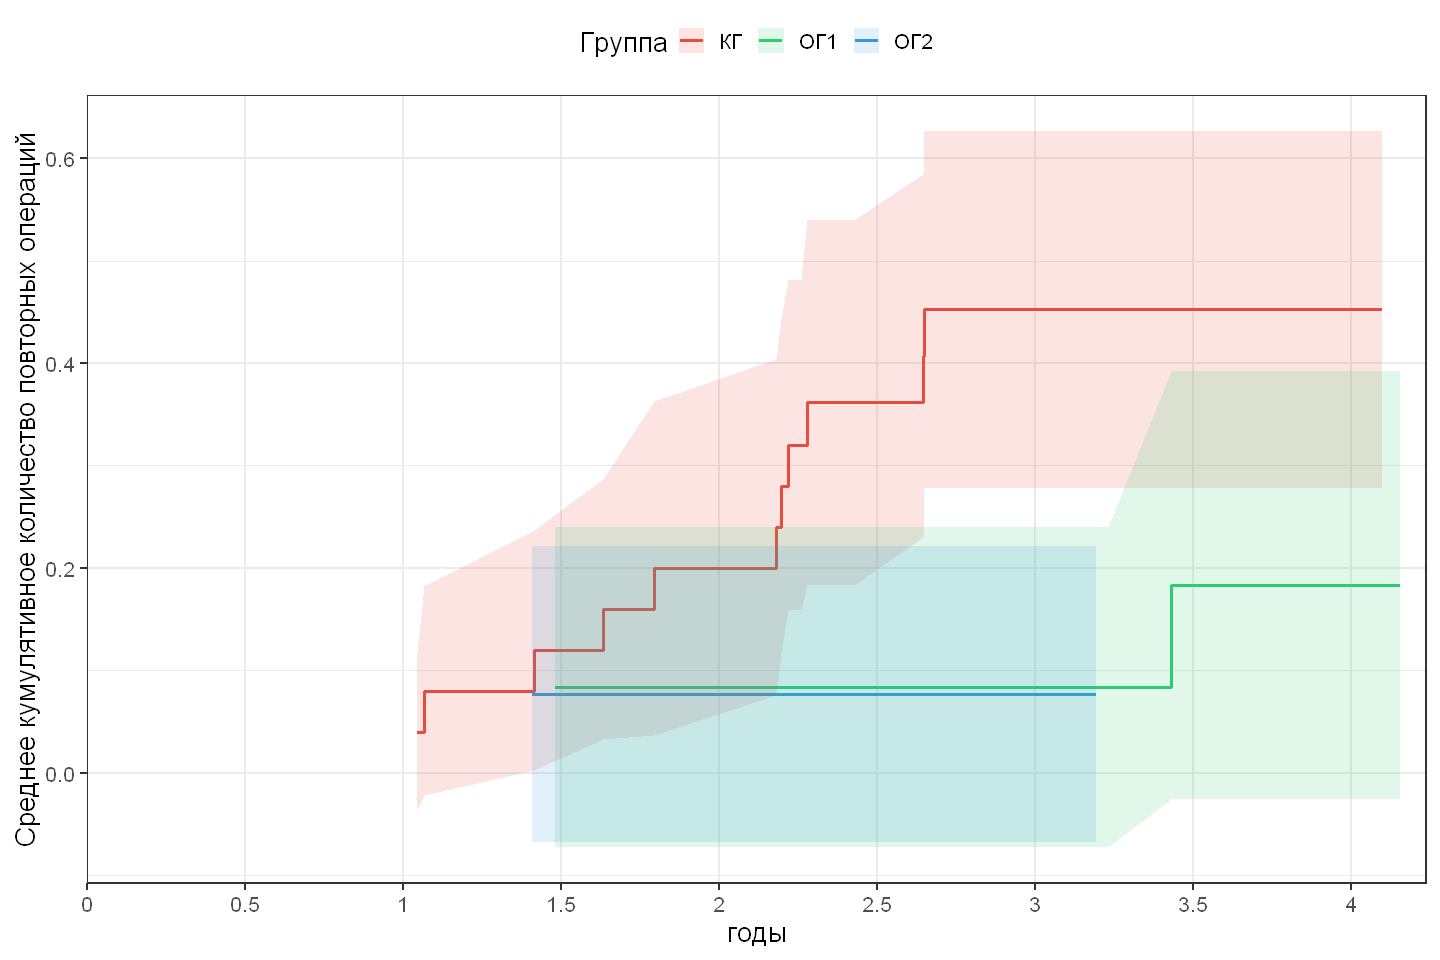

In [421]:
# Uses the Nelson-Aalen estimator applied to recurring events.
# survfit() with id= argument computes the MCF.

mcf_fit <- survfit(
  Surv(tstart, tstop, status) ~ group,
  data = long_df,
  id   = id       # identifies subject; cumhaz gives the MCF for recurring events
)

# Extract MCF data for all groups dynamically
mcf_data <- bind_rows(lapply(seq_along(group_levels), function(i) {
  tibble(
    time  = mcf_fit[i]$time,
    mcf   = mcf_fit[i]$cumhaz,
    lower = mcf_fit[i]$cumhaz - 1.96 * mcf_fit[i]$std.err,
    upper = mcf_fit[i]$cumhaz + 1.96 * mcf_fit[i]$std.err,
    group = group_levels[i]
  )
}))

mcf_plot <- ggplot(mcf_data, aes(x = time, y = mcf, color = group, fill = group)) +
  geom_step(linewidth = 1) +
  geom_ribbon(aes(ymin = lower, ymax = upper), alpha = 0.15, color = NA) +
  scale_color_manual(values = group_palette) +
  scale_fill_manual(values = group_palette) +
  scale_x_continuous(
    limits       = c(0, NA),
    breaks       = seq(0, max(mcf_data$time), by = six_months_days),
    labels       = function(x) round(x / 365.25, 1),
    minor_breaks = NULL,
    expand       = expansion(mult = c(0, 0.02))
  ) +
  labs(
    # title    = "Среднее значение кумулятивной функции (MCF) повторных операций",
    # subtitle = "Ожидаемое кумулятивное количество повторных операций на пациента с течением времени",
    x        = "годы",
    y        = "Среднее кумулятивное количество повторных операций",
    color    = "Группа",
    fill     = "Группа"
  ) +
  theme_bw(base_size = 16) +
  theme(legend.position = "top")

print(mcf_plot)


# 9. FOREST PLOT â€” all effect estimates in one figure

In [422]:
# All models report a ratio (HR or RR) of Group B relative to Group A.
#   ratio < 1  â†’  Group B has FEWER / LATER re-operations  (better)
#   ratio > 1  â†’  Group B has MORE  / EARLIER re-operations (worse)

# Collect all estimates
extract_hr <- function(fit, coef_row = 1) {
  s  <- summary(fit)
  ci <- exp(confint(fit))
  if ("conf.int" %in% names(s)) {
    hr <- s$conf.int[coef_row, 1]
    lo <- s$conf.int[coef_row, 3]
    hi <- s$conf.int[coef_row, 4]
    pv <- s$coefficients[coef_row, ncol(s$coefficients)]
  } else {
    hr <- exp(s$coefficients[coef_row, 1])
    lo <- ci[coef_row, 1]
    hi <- ci[coef_row, 2]
    pv <- s$coefficients[coef_row, 4]
  }
  list(est = hr, lo = lo, hi = hi, p = pv)
}

cox_e <- extract_hr(cox_fit)
ag_e  <- extract_hr(ag_fit)
pwp_e <- extract_hr(pwp_fit)

# Negative binomial rate ratio
nb_s  <- summary(nb_fit)
nb_ci <- exp(confint(nb_fit))
nb_e  <- list(
  est = exp(nb_s$coefficients["groupB", 1]),
  lo  = nb_ci["groupB", 1],
  hi  = nb_ci["groupB", 2],
  p   = nb_s$coefficients["groupB", 4]
)

forest_df <- tibble(
  Model  = factor(c(
                    "Cox PH\n(time to 1st re-op)",
                    "Andersen-Gill\n(all re-ops)",
                    "PWP\n(ordered re-ops)",
                    "Neg. Binomial\n(total count)"
                    ),
                    levels = rev(c(
                                  "Cox PH\n(time to 1st re-op)",
                                  "Andersen-Gill\n(all re-ops)",
                                  "PWP\n(ordered re-ops)",
                                  "Neg. Binomial\n(total count)"
                                  )
                                )
  ),
  Estimate = c(cox_e$est, ag_e$est, pwp_e$est, nb_e$est),
  Lower    = c(cox_e$lo,  ag_e$lo,  pwp_e$lo,  nb_e$lo),
  Upper    = c(cox_e$hi,  ag_e$hi,  pwp_e$hi,  nb_e$hi),
  P        = c(cox_e$p,   ag_e$p,   pwp_e$p,   nb_e$p),
  Type     = c("Time-to-event", "Time-to-event", "Time-to-event", "Count")
)

forest_df <- forest_df |>
  mutate(
    label  = sprintf("%.2f (%.2fâ€“%.2f)\np=%s",
                     Estimate, Lower, Upper,
                     ifelse(P < 0.001, "<0.001", sprintf("%.3f", P))),
    sig    = ifelse(P < 0.05, "Significant", "Non-significant"),
    colour = ifelse(Estimate < 1, "#2ECC71", "#E74C3C")
  )

forest_plot <- ggplot(forest_df,
                      aes(x = Estimate, y = Model, xmin = Lower, xmax = Upper)) +
  geom_vline(xintercept = 1, linetype = "dashed", colour = "grey50") +
  geom_errorbarh(aes(colour = colour), height = 0.2, linewidth = 0.8) +
  geom_point(aes(colour = colour, shape = sig), size = 3.5) +
  geom_text(aes(x = max(Upper) * 1.05, label = label),
            hjust = 0, size = 3, lineheight = 0.9) +
  scale_colour_identity() +
  scale_shape_manual(values = c("Significant" = 16, "Non-significant" = 1)) +
  scale_x_continuous(
    expand = expansion(mult = c(0.05, 0.45)),
    trans  = "log10"
  ) +
  labs(
    title    = "Group B vs Group A â€” Effect Estimates (Forest Plot)",
    subtitle = "Ratio < 1 (green): Group B has fewer/later re-operations (BETTER)\nRatio > 1 (red): Group B has more/earlier re-operations (WORSE)",
    x        = "Hazard Ratio / Rate Ratio (log scale)",
    y        = NULL,
    shape    = NULL
  ) +
  theme_bw(base_size = 12) +
  theme(legend.position = "bottom",
        panel.grid.minor = element_blank())

print(forest_plot)

Waiting for profiling to be done...



ERROR: Error in nb_s$coefficients["groupB", 1]: subscript out of bounds


# GROUP COMPARISON SUMMARY 

In [ ]:
# Helper: interpret ratio with direction
interpret <- function(label, est, lo, hi, p, unit = "re-ops") {
  direction <- if (est < 1) "FEWER" else "MORE"
  colour    <- if (est < 1) "BETTER" else "WORSE"
  sig_str   <- if (p < 0.05) 
                  sprintf("(p=%.4f, statistically significant)", p)
               else
                  sprintf("(p=%.4f, NOT significant)", p)
  pct       <- abs(1 - est) * 100
  cat(sprintf(
    "  %-35s  HR/RR = %.2f (95%% CI %.2f-%.2f)\n    â†’ Group B has %.1f%% %s %s than Group A  [%s]  %s\n\n",
    label, est, lo, hi, pct, direction, unit, colour, sig_str
  ))
}

# KM median re-operation-free survival
km_med <- surv_median(km_fit)

cat("--- Time to first Re-operation (Kaplan-Meier medians) ---\n")
for (i in seq_len(nrow(km_med))) {
  cat(sprintf("  %s:  median re-op-free time = %.1f months  (95%% CI %.1f-%.1f)\n",
              km_med$strata[i],
              km_med$median[i],
              km_med$lower[i],
              km_med$upper[i]))
}
p_logrank <- pchisq(logrank$chisq, df = length(logrank$n) - 1, lower.tail = FALSE)
cat(sprintf("  Log-rank p-value: %.4f  %s\n\n",
            p_logrank,
            ifelse(p_logrank < 0.05,
                   "â†’ Groups differ significantly in time to first re-operation.",
                   "â†’ No significant difference in time to first re-operation.")))

cat("--- Effect Estimates (Group B relative to Group A) ---\n")
interpret("Cox PH (time to 1st re-op)",  cox_e$est, cox_e$lo, cox_e$hi, cox_e$p)
interpret("Andersen-Gill (all re-ops)",  ag_e$est,  ag_e$lo,  ag_e$hi,  ag_e$p)
interpret("PWP (ordered re-ops)",        pwp_e$est, pwp_e$lo, pwp_e$hi, pwp_e$p)
interpret("Neg. Binomial (total count)", nb_e$est,  nb_e$lo,  nb_e$hi,  nb_e$p,
          unit = "re-ops per unit time")

# Overall verdict
all_ests <- c(cox_e$est, ag_e$est, pwp_e$est, nb_e$est)
any_sig  <- any(c(cox_e$p, ag_e$p, pwp_e$p, nb_e$p) < 0.05)
all_same_dir <- all(all_ests < 1) || all(all_ests > 1)

cat("--- OVERALL VERDICT ---\n")
if (all_same_dir && any_sig) {
  better <- if (all(all_ests < 1)) "B" else "A"
  worse  <- if (better == "B") "A" else "B"
  cat(sprintf(
    "  All models consistently show Group %s has BETTER outcomes\n  (fewer re-operations and/or longer time to re-operation)\n  compared to Group %s, and at least one result is statistically\n  significant.\n",
    better, worse
  ))
} else if (all_same_dir && !any_sig) {
  better <- if (all(all_ests < 1)) "B" else "A"
  cat(sprintf(
    "  All models point in the same direction (Group %s appears better)\n  but no result reaches statistical significance.\n  Consider increasing sample size.\n", better
  ))
} else {
  cat("  Results are inconsistent across models.\n")
  cat("  Check model assumptions and data quality.\n")
}